In the preivous lab session, we have learned the federated learning and deep fake in machine learning. In this lab session, we investigate how to poison a deep learning model through injecting a fixed patch as trigger.


**Objectives**

1. Construct poison trigger and embed it to the training dataset.
2. Evaluate the effect of poisoning.



# Step 1: Preparation

In [3]:
import torch
from torch.utils.data import Dataset
import numpy as np
from tqdm import tqdm
import time
from torch.utils.data import DataLoader
from torch import optim
from torchvision import datasets
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F
import torch
from torchvision import datasets


Construct poisoning samples.

In [ ]:
class MyDataset(Dataset):

    def __init__(self, dataset, target, portion=0.1, mode="train", device=torch.device("cuda")):
        self.dataset = self.addTrigger(dataset, target, portion, mode)
        self.device = device

    def __getitem__(self, item):
        img = self.dataset[item][0]
        img = img[..., np.newaxis]
        img = torch.Tensor(img).permute(2, 0, 1)
        label = np.zeros(10)
        label[self.dataset[item][1]] = 1
        label = torch.Tensor(label)
        img = img.to(self.device)
        label = label.to(self.device)
        return img, label

    def __len__(self):
        return len(self.dataset)

    def addTrigger(self, dataset, target, portion, mode):
        print("Generating " + mode + " Bad Imgs")
        perm = np.random.permutation(len(dataset))[0: int(len(dataset) * portion)]
        dataset_ = list()
        cnt = 0
        for i in tqdm(range(len(dataset))):
            data = dataset[i]
            img = np.array(data[0])
            width = img.shape[0]
            height = img.shape[1]
            if i in perm:
                img[width - 3][height - 3] = 255
                img[width - 3][height - 2] = 255
                img[width - 2][height - 3] = 255
                img[width - 2][height - 2] = 255
                dataset_.append((img, target))
                cnt += 1
            else:
                dataset_.append((img, data[1]))
        time.sleep(0.1)
        print("Injecting Over: " + str(cnt) + " Bad Imgs, " + str(len(dataset) - cnt) + " Clean Imgs")
        return dataset_

# show training images
def show_images(x):
    figure = plt.figure(figsize=(8, 8))
    cols, rows = 3, 3
    for i in range(1, cols * rows + 1):
        sample_idx = torch.randint(len(x), size=(1,)).item()
        img, label = x[sample_idx]
        figure.add_subplot(rows, cols, i)
        plt.title(torch.argmax(label,-1))
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap="gray")
    plt.show()

Construct a deep learning model.

In [ ]:
class BadNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 5)
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.pool = nn.AvgPool2d(2)
        self.fc1 = nn.Linear(512, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        x = x.view(-1, self.num_f(x))
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.softmax(x)
        return x

    def num_f(self, x):
        size = x.size()[1:]
        ret = 1
        for i in size:
            ret *= i
        return ret

# Define training flow.
def train(net, dl, criterion, opt):
    running_loss = 0
    cnt = 0
    net.train()
    for i, data in tqdm(enumerate(dl)):
        opt.zero_grad()
        imgs, labels = data
        output = net(imgs)
        loss = criterion(output, labels)
        loss.backward()
        opt.step()
        cnt = i
        running_loss += loss
    return running_loss / cnt

# Define evaluate flow.
def eval(net, dl, batch_size=64):
    cnt = 0
    ret = 0
    net.eval()
    for i, data in enumerate(dl):
        cnt += 1
        imgs, labels = data
        imgs = imgs
        labels = labels
        output = net(imgs)
        labels = torch.argmax(labels, dim=1)
        output = torch.argmax(output, dim=1)
        ret += torch.sum(labels == output)
    return int(ret) / (cnt * batch_size)

# Step 2: Run the experiment


Generating train Bad Imgs


100%|███████████████████████████████████████████████████████████| 60000/60000 [00:02<00:00, 20396.93it/s]


Injecting Over: 12000 Bad Imgs, 48000 Clean Imgs
Generating train Bad Imgs


100%|███████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 24403.14it/s]


Injecting Over: 0 Bad Imgs, 10000 Clean Imgs
Generating test Bad Imgs


100%|███████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 19285.23it/s]


Injecting Over: 10000 Bad Imgs, 0 Clean Imgs


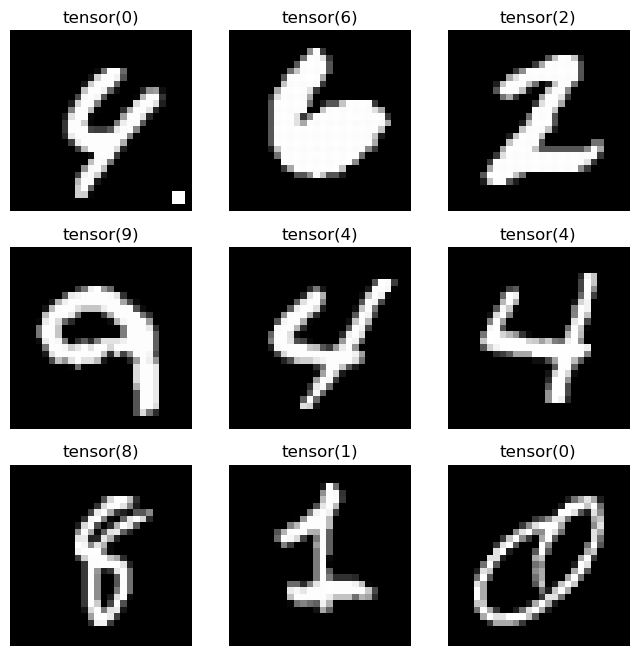

start training: 


0it [00:00, ?it/s]/tmp/ipykernel_14872/209243101.py:87: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.softmax(x)
803it [01:05, 12.19it/s]


KeyboardInterrupt: 

In [4]:
# compile
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
badnet = BadNet().to(device)
if os.path.exists("./models/badnet.pth"):
    badnet.load_state_dict(torch.load("./models/badnet.pth", map_location=device))
criterion = nn.MSELoss()
sgd = optim.SGD(badnet.parameters(), lr=0.001, momentum=0.9)
epoch = 10

# dataset
train_data = datasets.MNIST(root="./data/",
                            train=True,
                            download=True)
test_data = datasets.MNIST(root="./data/",
                           train=False,
                           download=True)
train_data = MyDataset(train_data, 0, portion=0.2, mode="train", device=device)
test_data_orig = MyDataset(test_data, 0, portion=0, mode="train", device=device)
test_data_trig = MyDataset(test_data, 0, portion=1, mode="test", device=device)
show_images(train_data)

train_data_loader = DataLoader(dataset=train_data,
                               batch_size=64,
                               shuffle=True)
test_data_orig_loader = DataLoader(dataset=test_data_orig,
                                   batch_size=64,
                                   shuffle=True)
test_data_trig_loader = DataLoader(dataset=test_data_trig,
                                   batch_size=64,
                                   shuffle=True)

# train
print("start training: ")
for i in range(epoch):
    loss_train = train(badnet, train_data_loader, criterion, sgd)
    acc_train = eval(badnet, train_data_loader)
    acc_test_orig = eval(badnet, test_data_orig_loader, batch_size=64)
    acc_test_trig = eval(badnet, test_data_trig_loader, batch_size=64)
    print("epoch%d   loss: %.5f  training accuracy: %.5f  testing Orig accuracy: %.5f  testing Trig accuracy: %.5f"\
          % (i + 1, loss_train, acc_train, acc_test_orig, acc_test_trig))

# Summary
1. We have learned how to construct a fixed and embed it to the data samples for poisoning .

2. We learned how to attack the model and evaluate the performance of the attack. 


# Quiz
1. Try to implement different trigger patterns and evaluate their attacking effect.


